In [12]:
from typing_extensions import TypedDict, List
from langgraph.graph import StateGraph, START,END

class AgentState(TypedDict):
  name: str
  age: str
  skills : List
  result : str
  

In [13]:
def greet_node(state : AgentState) -> AgentState:
  """Node to greet the user"""
  state['result'] = f"{state['name']}, Welcome to the system! "
  return state

def age_node(state: AgentState) -> AgentState:
  """Node to describe the age of user"""
  state['result'] = state['result'] + f"you are {state['age']} years old!"
  return state

def skill_node(state: AgentState) -> AgentState:
  """Node to display the skills of user"""
  state['result'] = state['result'] + f" You have skills in : {", ".join(state["skills"])}"
  return state

In [14]:
graph_builder = StateGraph(AgentState)

graph_builder.add_node("greeterNode" , greet_node)
graph_builder.add_node("ageNode" , age_node)
graph_builder.add_node("skillsNode" , skill_node)

graph_builder.add_edge(START, "greeterNode")
graph_builder.add_edge("greeterNode" , "ageNode")
graph_builder.add_edge("ageNode" , "skillsNode")
graph_builder.add_edge("skillsNode" , END)

graph = graph_builder.compile()

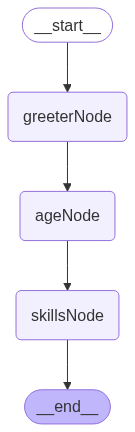

In [16]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [17]:
graph.invoke({"name" : "Dishant" , "age" : "21", "skills" : ["Javascript" , "Python"]})

{'name': 'Dishant',
 'age': '21',
 'skills': ['Javascript', 'Python'],
 'result': 'Dishant, Welcome to the system! you are 21 years old! You have skills in : Javascript, Python'}